In [10]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pickle

In [11]:
datas=pd.read_csv(r'C:\Users\Admin.DESKTOP-M4R2VLU\8weeksand9\data\final2.csv')

In [12]:

datas=datas.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'device_id'])

data = {'country': ['Canada','Romania','United States','Philippines','France','European Union','United Kingdom','Italy','United Arab Emirates']}
df = pd.DataFrame(data)

df['country'] = datas['country'].astype('category')

df

,country
0,Canada
1,Romania
2,Canada
3,United States
4,United States
5,United States
6,Philippines
7,United States
8,United States


In [13]:
# Merging the two DataFrames on the 'country' column
merged_data = datas.merge(df, on='country', how='inner')

In [14]:
merged_data

,user_id,signup_time,purchase_time,purchase_value,source,browser,sex,age,ip_address,class,ip_as_int,lower_bound_ip_address,upper_bound_ip_address,country,lower_bound_ip,upper_bound_ip
0,99475,2015-01-15 22:52:56,2015-03-21 05:26:58,55,Ads,IE,M,25,204.209.167.0,0,3436291840,204.209.167.0,204.209.167.255,Canada,3.436292e+09,3.436292e+09
1,99475,2015-01-15 22:52:56,2015-03-21 05:26:58,55,Ads,IE,M,25,204.209.167.0,0,3436291840,204.209.167.0,204.209.167.255,Canada,3.436292e+09,3.436292e+09
2,39268,2015-05-09 17:42:56,2015-06-04 05:13:18,36,SEO,IE,F,27,194.33.14.0,0,3256946176,194.33.14.0,194.33.14.255,Romania,3.256946e+09,3.256946e+09
3,92325,2015-01-16 19:47:30,2015-05-03 17:19:26,27,Direct,Chrome,M,30,208.88.184.0,0,3495475200,208.88.184.0,208.88.191.255,Canada,3.495475e+09,3.495477e+09
4,92325,2015-01-16 19:47:30,2015-05-03 17:19:26,27,Direct,Chrome,M,30,208.88.184.0,0,3495475200,208.88.184.0,208.88.191.255,Canada,3.495475e+09,3.495477e+09
5,390559,2015-07-09 06:36:13,2015-09-22 04:07:00,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09
6,390559,2015-07-09 06:36:13,2015-09-22 04:07:00,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09
7,390559,2015-07-09 06:36:13,2015-09-22 04:07:00,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09
8,390559,2015-07-09 06:36:13,2015-09-22 04:07:00,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09
9,390559,2015-07-09 06:36:13,2015-09-22 04:07:00,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09


In [15]:
#with open('log_reg.pkl', 'rb') as f:
    #datas = pickle.load(f)

from sklearn.preprocessing import OneHotEncoder
# Sample data preparation
X= datas.drop(columns=['class'])
y = datas['class']


# Process date-time column if it exists
if 'Time' in datas.columns:  # Replace 'date_column' with your actual column name
    datas['Time'] = pd.to_datetime(datas['Time'])  # Convert to datetime
    # Extract features from the date
    datas['year'] = datas['Time'].dt.year
    datas['month'] = datas['Time'].dt.month
    datas['day'] = datas['Time'].dt.day
    datas['hour'] = datas['Time'].dt.hour  # Corrected this line
    datas['day_of_week'] = datas['Time'].dt.dayofweek
    datas.drop('Time', axis=1, inplace=True)  # Drop the original date column

if 'signup_time' in datas.columns:  # Replace with your actual date column names
    datas['signup_time'] = pd.to_datetime(datas['signup_time'])
if 'purchase_time' in datas.columns:
    datas['purchase_time'] = pd.to_datetime(datas['purchase_time'])

# Extract features from the purchase_time
    datas['purchase_hour'] = datas['purchase_time'].dt.hour
    datas['purchase_day'] = datas['purchase_time'].dt.day
    datas['purchase_month'] = datas['purchase_time'].dt.month
    datas['purchase_year'] = datas['purchase_time'].dt.year
    datas['purchase_day_of_week'] = datas['purchase_time'].dt.dayofweek

# Drop the original date-time columns if no longer needed
    datas.drop(['signup_time', 'purchase_time'], axis=1, inplace=True)

# Identify and encode categorical columns
categorical_cols = datas.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    # Use sparse_output instead of sparse
    encoder = OneHotEncoder(sparse_output=True, max_categories=10)  # Limit to top 10 categories if possible
    X_encoded = encoder.fit_transform(datas[categorical_cols])
    
    # Concatenate the sparse matrix with numeric features
    X_fraud_numeric = datas.drop(columns=categorical_cols).reset_index(drop=True)
    X_fraud = pd.concat([X_fraud_numeric, pd.DataFrame.sparse.from_spmatrix(X_encoded)], axis=1)

# Convert column names to strings
X_fraud.columns = X_fraud.columns.astype(str)



In [16]:
pd.merge(datas, df)



,user_id,purchase_value,source,browser,sex,age,ip_address,class,ip_as_int,lower_bound_ip_address,upper_bound_ip_address,country,lower_bound_ip,upper_bound_ip,purchase_hour,purchase_day,purchase_month,purchase_year,purchase_day_of_week
0,99475,55,Ads,IE,M,25,204.209.167.0,0,3436291840,204.209.167.0,204.209.167.255,Canada,3.436292e+09,3.436292e+09,5,21,3,2015,5
1,99475,55,Ads,IE,M,25,204.209.167.0,0,3436291840,204.209.167.0,204.209.167.255,Canada,3.436292e+09,3.436292e+09,5,21,3,2015,5
2,39268,36,SEO,IE,F,27,194.33.14.0,0,3256946176,194.33.14.0,194.33.14.255,Romania,3.256946e+09,3.256946e+09,5,4,6,2015,3
3,92325,27,Direct,Chrome,M,30,208.88.184.0,0,3495475200,208.88.184.0,208.88.191.255,Canada,3.495475e+09,3.495477e+09,17,3,5,2015,6
4,92325,27,Direct,Chrome,M,30,208.88.184.0,0,3495475200,208.88.184.0,208.88.191.255,Canada,3.495475e+09,3.495477e+09,17,3,5,2015,6
5,390559,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09,4,22,9,2015,1
6,390559,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09,4,22,9,2015,1
7,390559,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09,4,22,9,2015,1
8,390559,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09,4,22,9,2015,1
9,390559,51,Ads,Safari,M,24,96.40.0.0,0,1613234176,96.40.0.0,96.41.255.255,United States,1.613234e+09,1.613365e+09,4,22,9,2015,1


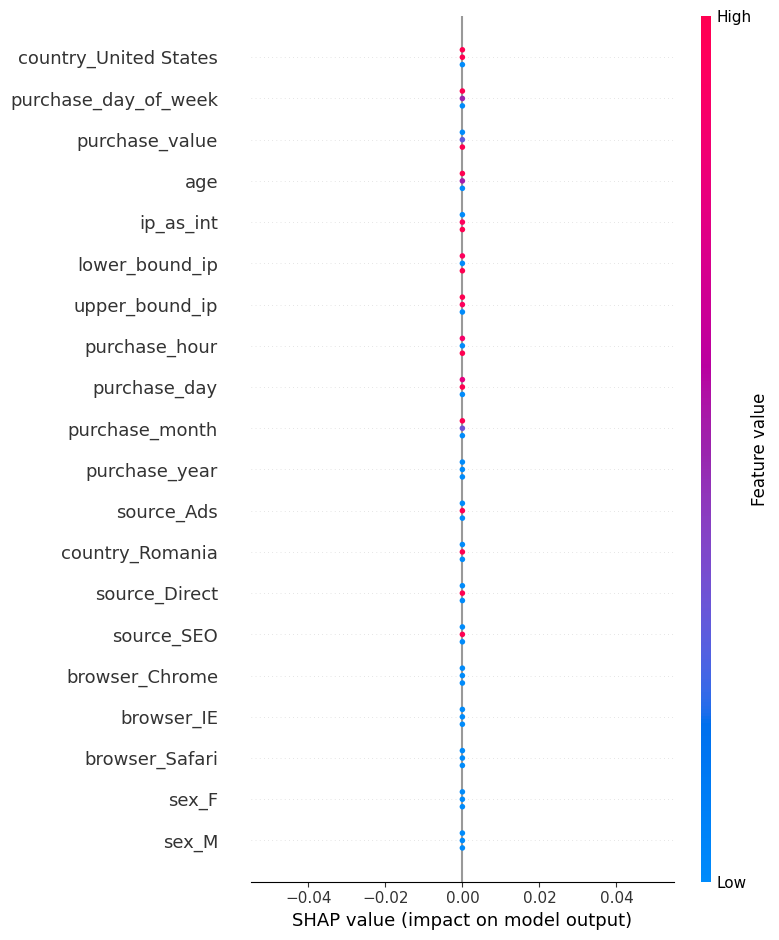

AttributeError: 'PermutationExplainer' object has no attribute 'expected_value'

In [17]:
from sklearn.preprocessing import OneHotEncoder
import socket
import struct

# Assuming 'datas' is your DataFrame
encoder = OneHotEncoder()
encoded = encoder.fit_transform(datas[['source', 'browser','sex','country']]).toarray()

# Combine the new encoded features with the rest of your DataFrame
df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['source', 'browser','sex','country']))
datas = datas.drop(['source', 'browser','sex','country'], axis=1)
datas = pd.concat([datas.reset_index(drop=True), df_encoded], axis=1)

#datas['lower_bound_ip'] = datas['lower_bound_ip_address'].apply(float)
#datas['upper_bound_ip_address'] = datas['upper_bound_ip_address'].apply(float)

datas.drop(['upper_bound_ip_address', 'lower_bound_ip_address','ip_address'], axis=1, inplace=True)


# Feature and Target Separation for Credit Card Dataset
X = datas.drop(columns=['class'])  # Features
y = datas['class']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.Explainer(model.predict_proba, X_train)



# Calculate SHAP values
shap_values = explainer(X_test)

# Create summary plot
shap.summary_plot(shap_values, X_test)

# Create force plot for the first instance
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0], X_test.iloc[0])


In [7]:
import shap

# Assuming you have your model and data setup as before
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Create summary plot
shap.summary_plot(shap_values[1], X_test)

# Create force plot for the first instance
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test.iloc[0])


AssertionError: Summary plots need a matrix of shap_values, not a vector.

In [7]:
datas

,user_id,purchase_value,age,ip_address,class,ip_as_int,lower_bound_ip_address,upper_bound_ip,purchase_hour,purchase_day,...,source_SEO,browser_Chrome,browser_IE,browser_Safari,sex_F,sex_M,country_Canada,country_Philippines,country_Romania,country_United States
0,99475,55,25,204.209.167.0,0,3436291840,204.209.167.0,3.436292e+09,5,21,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,39268,36,27,194.33.14.0,0,3256946176,194.33.14.0,3.256946e+09,5,4,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,92325,27,30,208.88.184.0,0,3495475200,208.88.184.0,3.495477e+09,17,3,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,390559,51,24,96.40.0.0,0,1613234176,96.40.0.0,1.613365e+09,4,22,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,383733,42,45,206.197.207.0,0,3469070080,206.197.207.0,3.469070e+09,23,22,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,13614,24,18,199.59.108.0,0,3342560256,199.59.108.0,3.342561e+09,14,22,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6,112145,60,40,103.21.168.0,0,1729472512,103.21.168.0,1.729474e+09,0,12,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7,34805,19,35,98.64.0.0,0,1648361472,98.64.0.0,1.650459e+09,13,27,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8,385983,22,36,199.101.40.0,0,3345295360,199.101.40.0,3.345296e+09,11,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
datas = OneHotEncoder().fit_transform(datas.columns).toarray()
sc = StandardScaler().fit(datas)
# Verify the conversion
#print(datas.dtypes)

# Continue with preprocessing (if needed)
# For example, you might want to one-hot encode these columns


# Now you can proceed with your modeling

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train a model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Create SHAP explainer with training data as background
explainer = shap.Explainer(model.predict_proba, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Create summary plot
shap.summary_plot(shap_values, X_test)

# Create force plot for the first instance
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0], X_test.iloc[0])

SystemError: <built-in function isinstance> returned a result with an exception set